In [1]:
import grib2io
import inspect
import wget
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import geopandas as gpd
from shapely.geometry import Polygon
import geodatasets

In [3]:
gdf = gpd.read_file('Boundaries')
#gdf.head()

In [43]:
#g = grib2io.open('Data/flxf.01.2016060700.201606.avrg.grib.00Z.grb2')
g = grib2io.open('Data/flxf.01.2016060700.201606.avrg.grib.12Z.grb2')

#g = grib2io.open('Data/flxf.01.2016060700.201606.avrg.grib.grb2')

msgs = g.select(shortName="TMP",level="surface")
for msg in msgs:
       print(msg.shortName,msg.level,msg.valueOfForecastTime,msg.unitOfTimeRangeOfStatisticalProcess)


TMP surface 0 3 - Month


In [44]:
msg

Section 0: discipline = 0 - Meteorological Products
Section 1: originatingCenter = 7 - US National Weather Service - NCEP (WMC)
Section 1: originatingSubCenter = 0 - None
Section 1: masterTableInfo = 2 - Version Implemented on 4 November 2003
Section 1: localTableInfo = 1 - Number of local table version used.
Section 1: significanceOfReferenceTime = 1 - Start of Forecast
Section 1: year = 2016
Section 1: month = 6
Section 1: day = 7
Section 1: hour = 0
Section 1: minute = 0
Section 1: second = 0
Section 1: refDate = 2016-06-07 00:00:00
Section 1: productionStatus = 0 - Operational Products
Section 1: typeOfData = 1 - Forecast Products
Section 3: sourceOfGridDefinition = 0 - Specified in Code Table 3.1
Section 3: numberOfDataPoints = 72960
Section 3: interpretationOfListOfNumbers = 0 - There is no appended list
Section 3: gridDefinitionTemplateNumber = 40 - Gaussian Latitude/Longitude
Section 3: shapeOfEarth = 6 - Earth assumed spherical with radius = 6,371,229.0 m
Section 3: earthRadiu

In [3]:


# tl 41.01028758048584, -109.03902430239825  250.961
# tr 41.01028758048584, -102.1615830612143   257.839
# bl 37.01715874548232, -109.0829696138435
# br 37.01715874548232, -102.07369243832379  


In [4]:
msg.data.shape

(190, 384)

In [37]:
# Extract Out Colorado
lats = msg.lats
lons = msg.lons

dat = msg.data
print(len(dat))
latslons = {} 
index=0
for j,d in enumerate(dat):
    for i,val in enumerate(d):
        lat = lats[j,i]
        lon = lons[j,i]
        index+=1
        if lat > 37.0 and lat < 41.1 and lon > 250.9 and lon < 258:
        #    print(i,j,lats[j,i],lons[j,i])
            if lat not in latslons:
                latslons[lat]={}
            if lon not in latslons[lat]:
                latslons[lat][lon]={}
                
            latslons[lat][lon]["i"]= i
            latslons[lat][lon]["j"]= j
            latslons[lat][lon]["index"]= index
            latslons[lat][lon]["data"]= dat[j,i]
            
            

#data = dat[268:276][52:56]

190


In [38]:
data = np.array([])
for d in dat[52:56]:
    for dd in d[268:276]:
       data= np.append(data,dd)

In [8]:
len(data)

32

In [39]:
for lat in latslons.keys():
    for lon in latslons[lat].keys():
        i=latslons[lat][lon]["i"]
        j=latslons[lat][lon]["j"]
        index=latslons[lat][lon]["index"]
        dd=latslons[lat][lon]["data"]
        
        print(index,i,j,lat,lon,dd)

20237 268 52 40.15731379530128 251.2496501305483 292.5317
20238 269 52 40.15731379530128 252.1871488250653 289.6325
20239 270 52 40.15731379530128 253.12464751958225 285.4053
20240 271 52 40.15731379530128 254.06214621409922 287.6453
20241 272 52 40.15731379530128 254.9996449086162 292.1029
20242 273 52 40.15731379530128 255.93714360313317 296.19568
20243 274 52 40.15731379530128 256.87464229765015 298.4261
20244 275 52 40.15731379530128 257.8121409921671 299.0597
20621 268 53 39.2124374010912 251.2496501305483 292.9797
20622 269 53 39.2124374010912 252.1871488250653 288.7781
20623 270 53 39.2124374010912 253.12464751958225 284.8357
20624 271 53 39.2124374010912 254.06214621409922 287.2933
20625 272 53 39.2124374010912 254.9996449086162 291.0213
20626 273 53 39.2124374010912 255.93714360313317 295.6869
20627 274 53 39.2124374010912 256.87464229765015 298.8101
20628 275 53 39.2124374010912 257.8121409921671 299.81488
21005 268 54 38.26756086094803 251.2496501305483 293.36368
21006 269 5

In [10]:
#  Separate Lats and Lons for plotting
lats=[]
lons=[]
X=[]
Y=[]
nl=0
for lat,dct in latslons.items():
    Y.append(lat)
    nl+=1
    for lon in dct.keys():
        lons.append(lon)
        lats.append(lat)
        
        if nl == 1:
            X.append(lon)
X= np.array(X)
Y= np.array(Y)   


In [11]:
X,Y = np.meshgrid(X,Y)

In [12]:
X.shape

(4, 8)

In [15]:
print(Y[0,0],Y[-1,-1])
print(X[0,0],X[-1,-1])


40.15731379530128 37.3226841834057
251.2496501305483 257.8121409921671


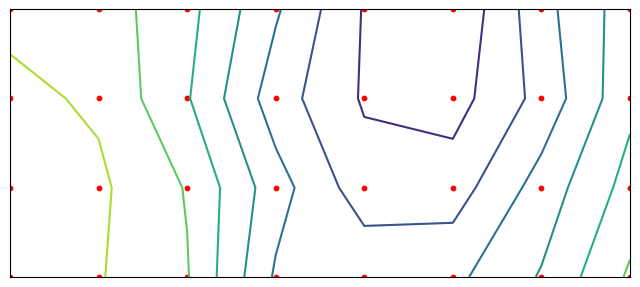

In [17]:
fig = plt.figure(figsize=(8, 6), edgecolor='b')

my_map = Basemap(projection='cyl',
               llcrnrlat=Y[-1,-1], urcrnrlat=Y[0,0],resolution="l",
            llcrnrlon=X[-1,-1], urcrnrlon=X[0,0])
 
#my_map.drawcoastlines()
my_map.drawstates()
my_map.scatter(lons, lats, latlon=True,c="red",s=10)
my_map.contour(X,Y,data.reshape(4,8))


In [ ]:
msg
for i in inspect.getmembers(msg):
     
    # to remove private and protected
    # functions
    if not i[0].startswith('_'):
         
        # To remove other methods that
        # doesnot start with a underscore
        if not inspect.ismethod(i[1]): 
            print(i[0],type(i[1]))

In [4]:
h = grib2io.open('Data/flxf.01.2016060700.201606.avrg.grib.grb2')
msgsh = h.select(shortName="TMP",level="surface")
for msg in msgsh:
       print(msg.shortName,msg.level,msg.valueOfForecastTime,msg.unitOfTimeRangeOfStatisticalProcess)

TMP surface 0 3 - Month


In [ ]:
msg

In [65]:

delta = 0.025

x = y = np.arange(-3.0, 3.01, delta)
X, Y = np.meshgrid(x, y)
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X - 1)**2 - (Y - 1)**2)
Z = (Z1 - Z2) * 2

nr, nc = Z.shape

# put NaNs in one corner:
Z[-nr // 6:, -nc // 6:] = np.nan
# contourf will convert these to masked


Z = np.ma.array(Z)
# mask another corner:
Z[:nr // 6, :nc // 6] = np.ma.masked

# mask a circle in the middle:
interior = np.sqrt(X**2 + Y**2) < 0.5
Z[interior] = np.ma.masked

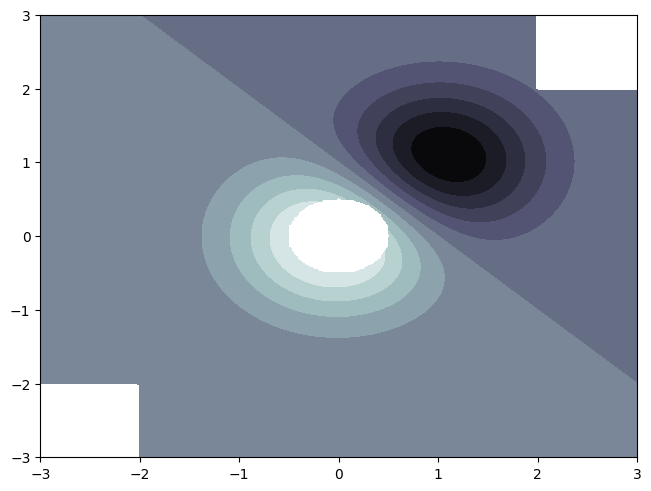

In [66]:
fig1, ax2 = plt.subplots(layout='constrained')
CS = ax2.contourf(X, Y, Z, 10, cmap=plt.cm.bone)

In [67]:
X

array([[-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
       [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
       [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
       ...,
       [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
       [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ],
       [-3.   , -2.975, -2.95 , ...,  2.95 ,  2.975,  3.   ]])

In [68]:
Y

array([[-3.   , -3.   , -3.   , ..., -3.   , -3.   , -3.   ],
       [-2.975, -2.975, -2.975, ..., -2.975, -2.975, -2.975],
       [-2.95 , -2.95 , -2.95 , ..., -2.95 , -2.95 , -2.95 ],
       ...,
       [ 2.95 ,  2.95 ,  2.95 , ...,  2.95 ,  2.95 ,  2.95 ],
       [ 2.975,  2.975,  2.975, ...,  2.975,  2.975,  2.975],
       [ 3.   ,  3.   ,  3.   , ...,  3.   ,  3.   ,  3.   ]])

## Create Select Function

In [2]:

def extractData(file,latBottom,latTop,lonLeft,lonRight):
    g = grib2io.open(f'Data/{file}')
#    msgs = g.select(shortName="TMP",level="surface")
    msgs = g.select(level="surface")
    
    for msg in msgs:
        print(msg.fullName,msg.shortName,msg.level,msg.valueOfForecastTime,msg.unitOfTimeRangeOfStatisticalProcess)
    
        lats = msg.lats
        lons = msg.lons
        
        dat = msg.data
        print(len(dat))
        latslons = {} 
        for j,d in enumerate(dat):
            for i,val in enumerate(d):
                lat = lats[j,i]
                lon = lons[j,i]
                if lat > latBottom and lat < latTop and lon > lonLeft and lon < lonRight:
                #    print(i,j,lats[j,i],lons[j,i])
                    if lat not in latslons:
                        latslons[lat]={}
                    if lon not in latslons[lat]:
                        latslons[lat][lon]={}
                        
                    latslons[lat][lon]["i"]= i
                    latslons[lat][lon]["j"]= j
        data = np.array([])
        for d in dat[52:56]:
            for dd in d[268:276]:
               data= np.append(data,dd)

    return data,latslons,msg


dat,latlons,msg = extractData("flxf.01.2013102100.201404.avrg.grib.grb2",37.0,41.1,250.9,258)

Momentum Flux, U-Component UFLX surface 6 3 - Month
190
Momentum Flux, V-Component VFLX surface 6 3 - Month
190
Sensible Heat Net Flux SHTFL surface 6 3 - Month
190
Latent Heat Net Flux LHTFL surface 6 3 - Month
190
Temperature TMP surface 6 3 - Month
190
Water Equivalent of Accumulated Snow Depth WEASD surface 6 3 - Month
190
Downward Long-Wave Rad. Flux DLWRF surface 6 3 - Month
190
Upward Long-Wave Rad. Flux ULWRF surface 6 3 - Month
190
Upward Short-Wave Radiation Flux USWRF surface 6 3 - Month
190
Downward Short-Wave Radiation Flux DSWRF surface 6 3 - Month
190
UV-B Downward Solar Flux DUVB surface 6 3 - Month
190
Clear sky UV-B Downward Solar Flux CDUVB surface 6 3 - Month
190
Precipitation Rate PRATE surface 6 3 - Month
190
Convective Precipitation Rate CPRAT surface 6 3 - Month
190
Ground Heat Flux GFLUX surface 6 3 - Month
190
Land Cover (0=sea, 1=land) LAND surface 6 3 - Month
190
Ice Cover ICEC surface 6 3 - Month
190
Pressure PRES surface 6 3 - Month
190
Water Runoff WATR s

In [ ]:
dir(msg)

In [ ]:
#  Separate Lats and Lons for plotting
lats=[]
lons=[]
X=[]
Y=[]
nl=0
for lat,dct in latslons.items():
    Y.append(lat)
    nl+=1
    for lon in dct.keys():
        lons.append(lon)
        lats.append(lat)
        
        if nl == 1:
            X.append(lon)
X= np.array(X)
Y= np.array(Y)   

X,Y = np.meshgrid(X,Y)

In [ ]:
fig = plt.figure(figsize=(8, 6), edgecolor='b')

my_map = Basemap(projection='cyl',
               llcrnrlat=Y[-1,-1], urcrnrlat=Y[0,0],resolution="l",
            llcrnrlon=X[-1,-1], urcrnrlon=X[0,0])
 
#my_map.drawcoastlines()
my_map.drawstates()
my_map.scatter(lons, lats, latlon=True,c="red",s=10)
my_map.contour(X,Y,data.reshape(4,8))
